In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qutip_trap.interop.qiskit import QutipTrapProvider

backend = QutipTrapProvider().get_backend("yb171_chain", n_ions=3)      # a backend on presets.yb171_chain(2)

In [2]:
ghz = QuantumCircuit(3)
ghz.h(0)
ghz.cx(0, 1)
ghz.cx(1, 2)
ghz.measure_all()
job = backend.run(transpile(ghz, backend), shots=1000)

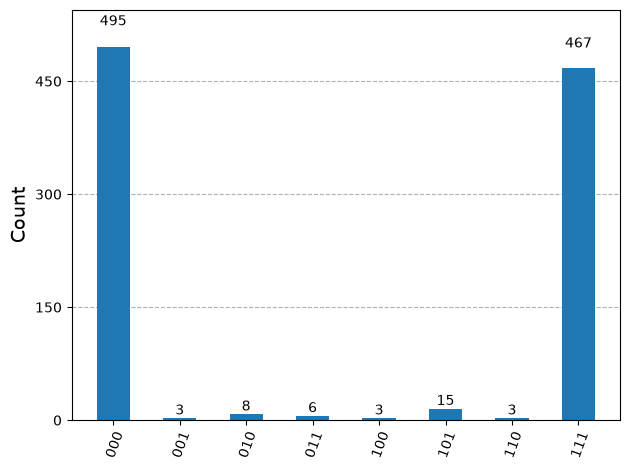

Diagnostics(level='GATE_LOCAL', space=HilbertSpace(ion_dims=(2, 2, 2), resolved=(ModeTruncation(mode=3, d=11, expected_n_range=(0, 4), eta_max=0.14707310625141579, element_tol=None), ModeTruncation(mode=4, d=12, expected_n_range=(0, 5), eta_max=0.12138845499386197, element_tol=None), ModeTruncation(mode=5, d=14, expected_n_range=(0, 7), eta_max=0.09623734290525889, element_tol=None)), enr_group=None, frozen=(0, 1, 2, 6, 7, 8), ions=(), dropped=(0, 1, 2, 6, 7, 8)), mode_class={0: 'dropped', 1: 'dropped', 2: 'dropped', 3: 'resolved', 4: 'resolved', 5: 'resolved', 6: 'dropped', 7: 'dropped', 8: 'dropped'}, run_state=RunState(order=(0, 1, 2), dark=frozenset(), lost=frozenset(), events=()), wall_clock_span_s=7.986672800307585, boundary_population={3: 2.230695972976986e-09, 4: 2.8440475781911817e-09, 5: 5.098871894780943e-08}, margin_levels={3: 6, 4: 6, 5: 6}, dropped_modes=(0, 1, 2, 6, 7, 8), frozen_contribution={}, integrator='dop853[propagator],exact,dop853', tolerances=(1e-10, 1e-08), sa

In [3]:
display(plot_histogram(job.result().get_counts()))          # {'000': ..., '111': ..., ...}
print(job.results[0].diagnostics)   # the qutip-trap Result behind every experiment, with its diagnostics